In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# choose a benchmark or your own objective
from math import sin, sqrt
import numpy as np
from models.abcng import ABCNG

def my_objective(x: np.ndarray) -> float:
    # Example: Sphere
    return float(np.sum(x**2))

# instantiate and run
opt = ABCNG(func=my_objective, dim=30, bounds=(-100, 100),
            pop_size=50, max_evals=5000*30, seed=123)
gbest, gval, hist = opt.run()
print("Best value:", gval)


Best value: 2.7365932014655372e-164


In [3]:
# Load ABCNG flags from .env
from tools.env_config import load_env, get_abcng_kwargs

env = load_env()
abcng_kwargs = get_abcng_kwargs(env)
print(abcng_kwargs)


{'use_gbest': True, 'use_adaptive_k': True, 'use_gaussian': True, 'neighbor_mode': 'neighbor', 'noise_model': 'gaussian', 'k_fixed': True, 'update_dim_mode': 'all'}


[{'function': 'sphere',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 2.38217229698558e-170,
  'abc_median_final': 715.3483464338865},
 {'function': 'rastrigin',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 72.63170727411051,
  'abc_median_final': 257.5295883745413},
 {'function': 'rosenbrock',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 0.5643895277184725,
  'abc_median_final': 1411956.0833617076},
 {'function': 'ackley',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 2.3619567562648816,
  'abc_median_final': 8.46895551268856}]

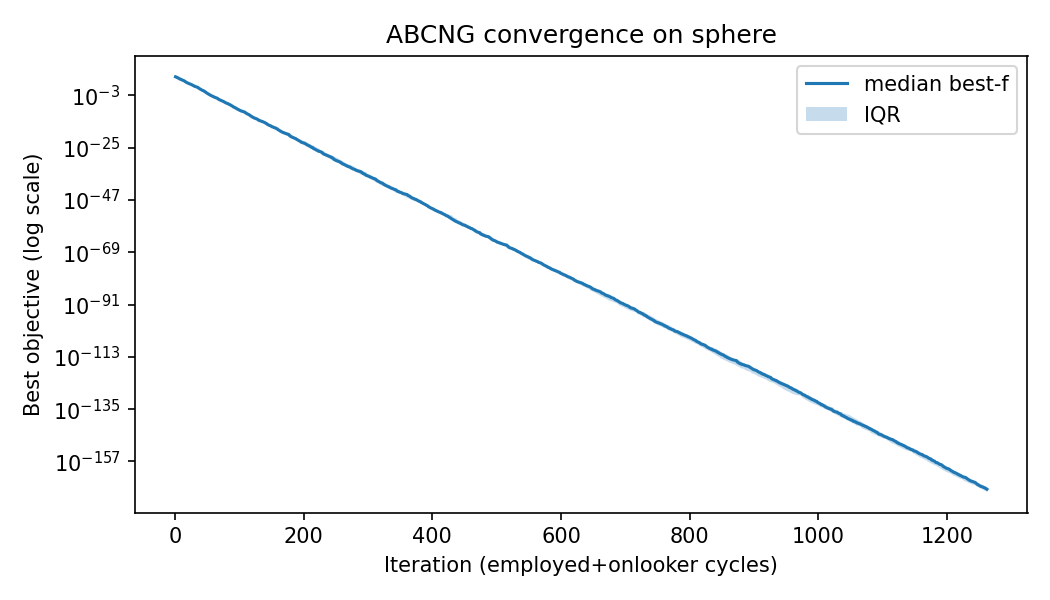

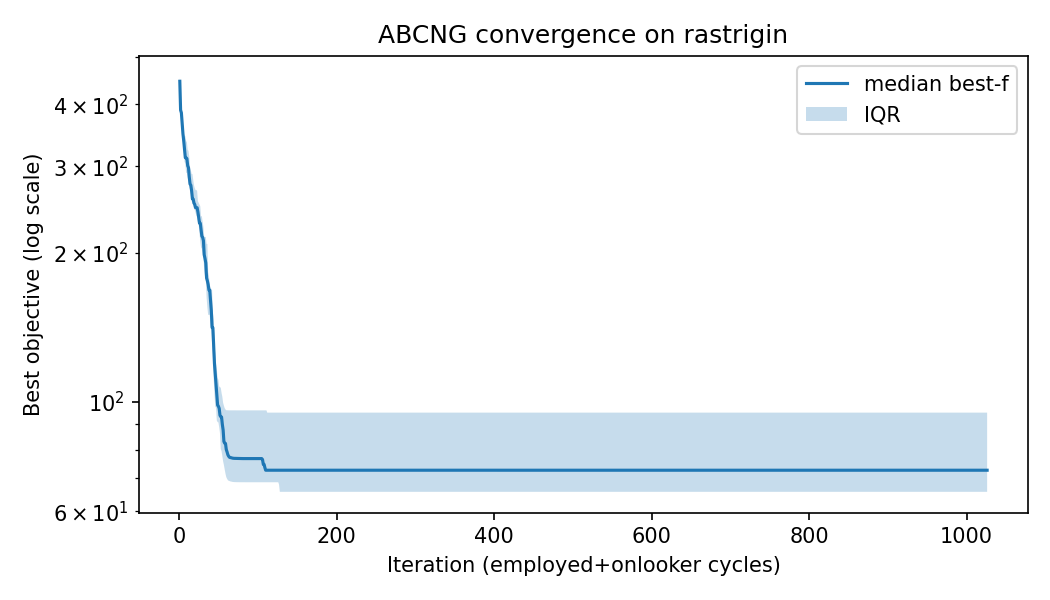

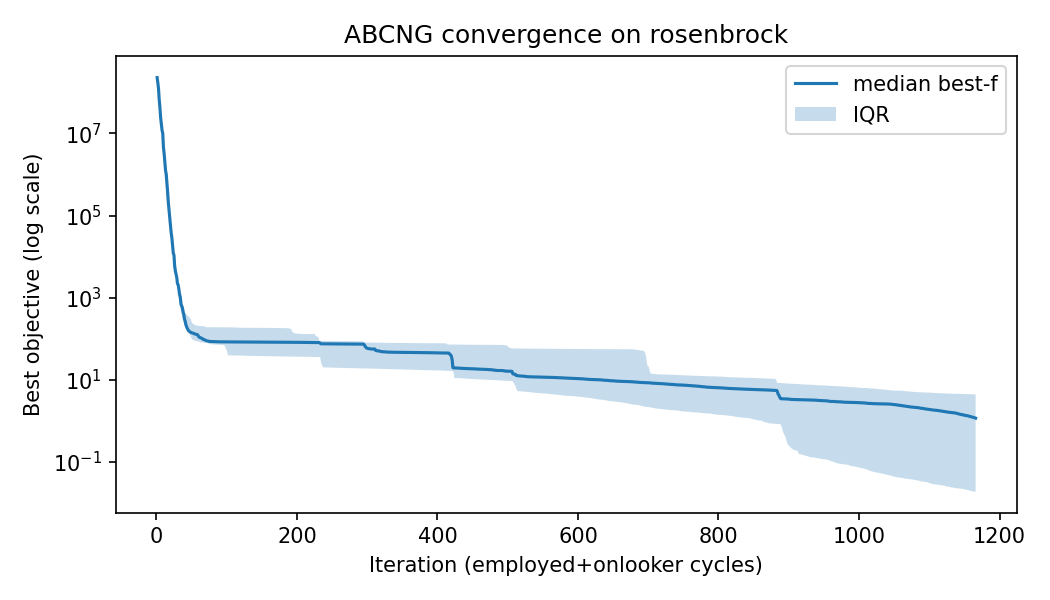

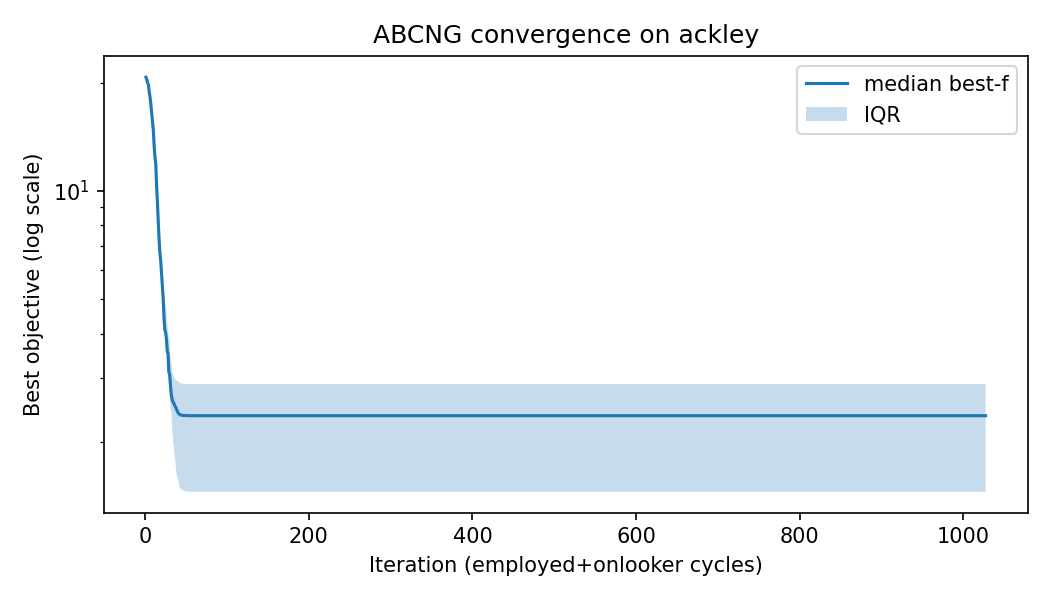

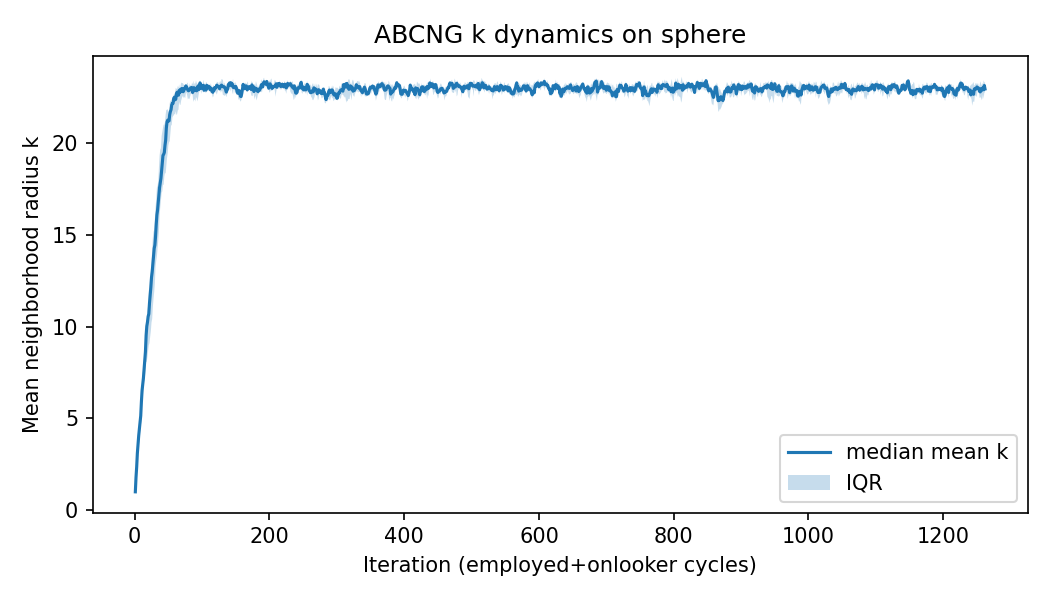

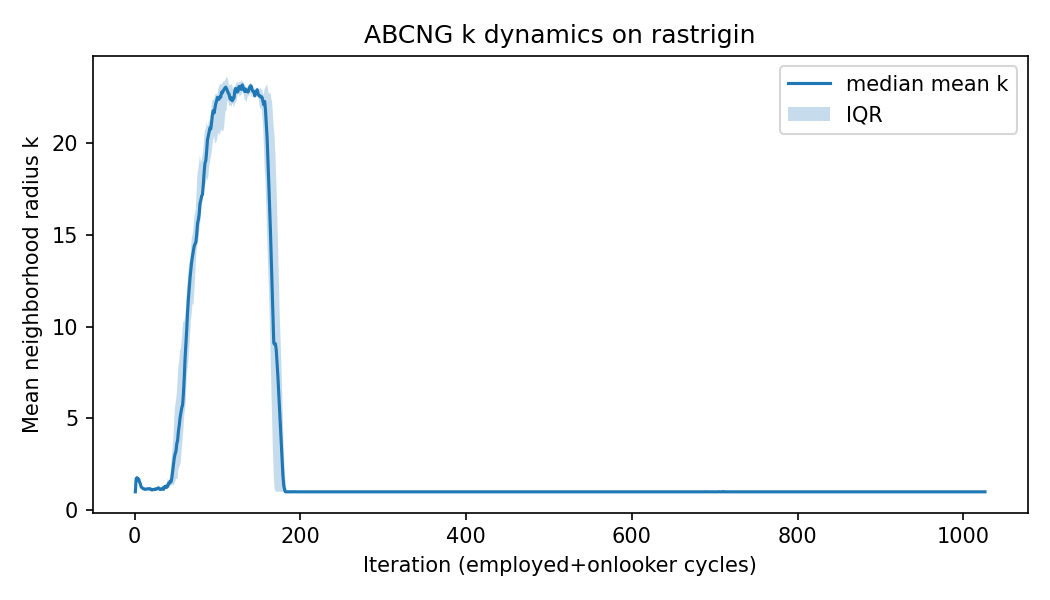

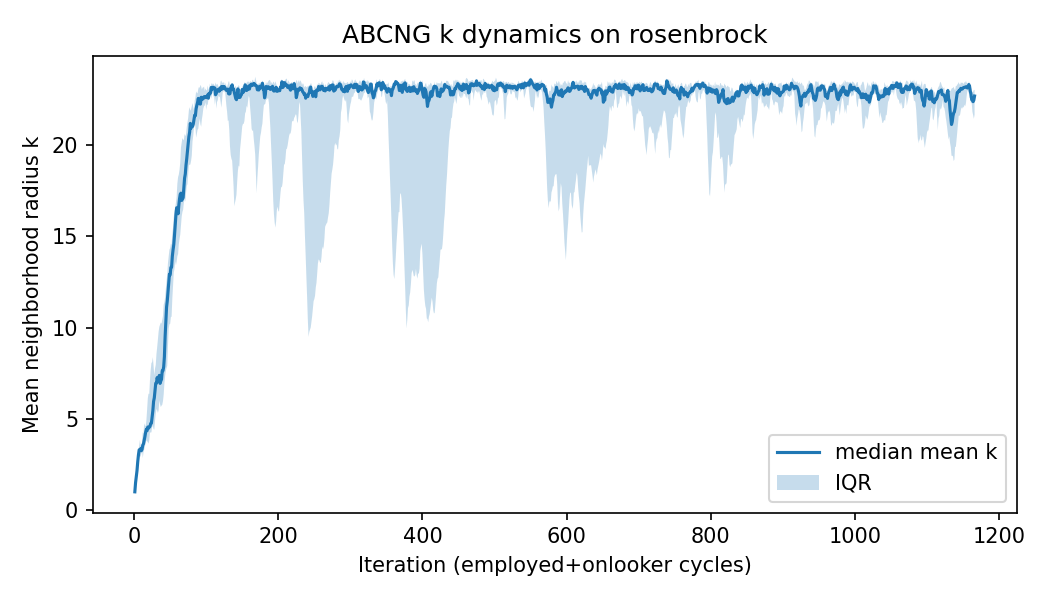

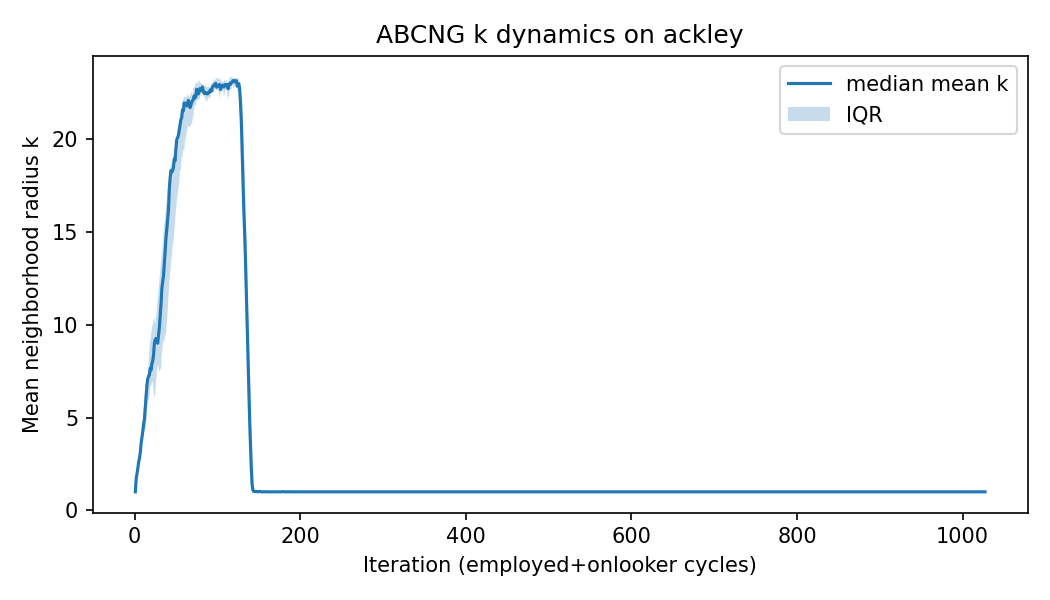

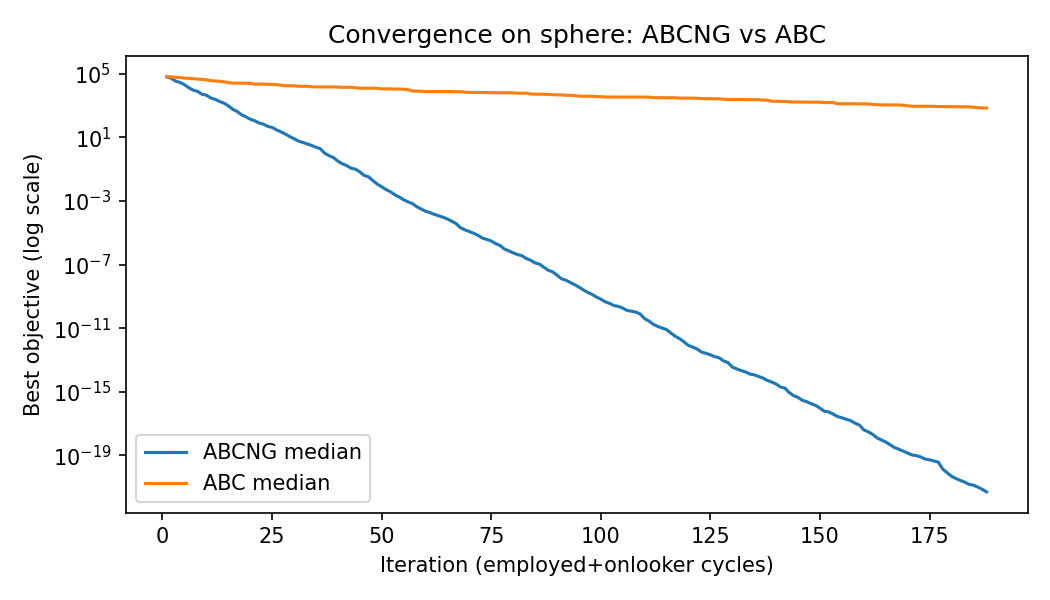

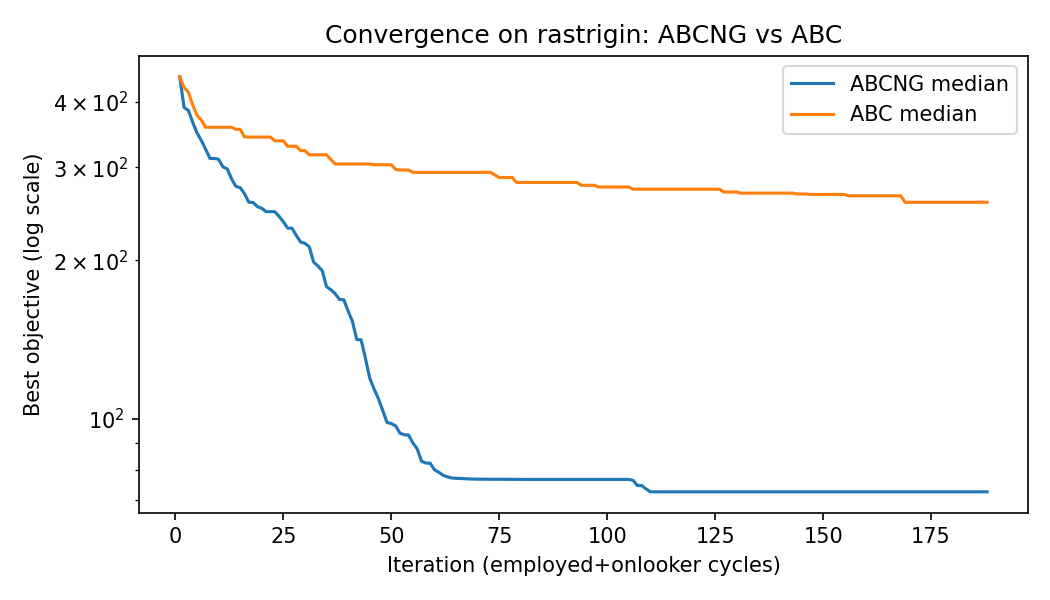

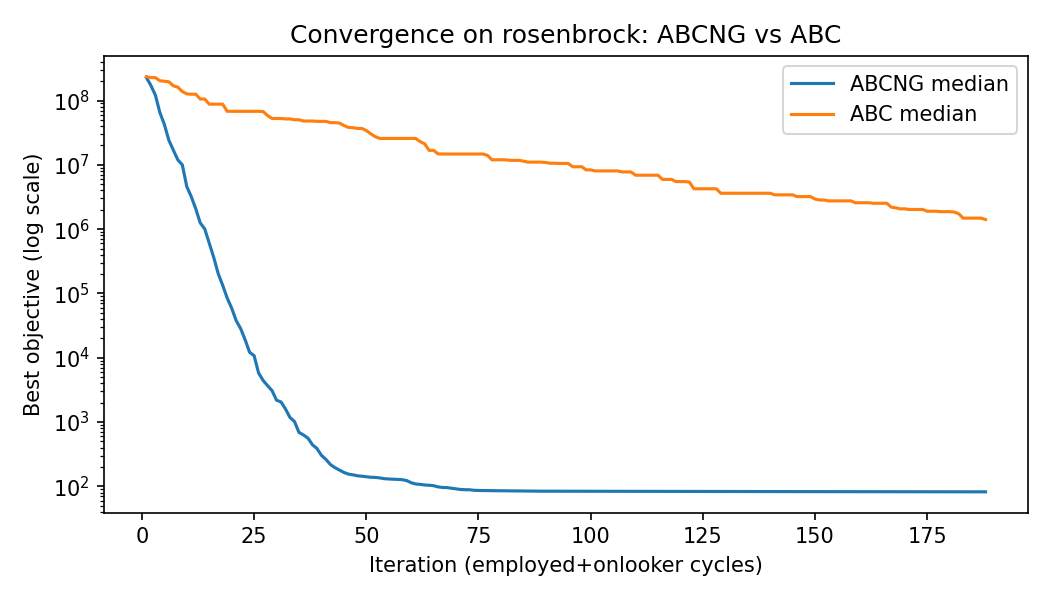

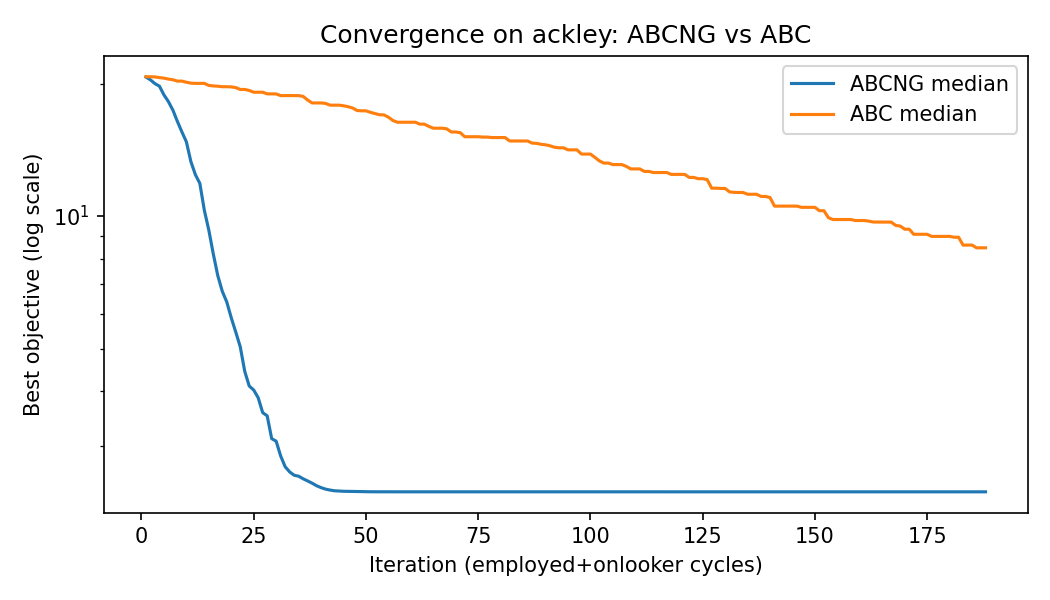

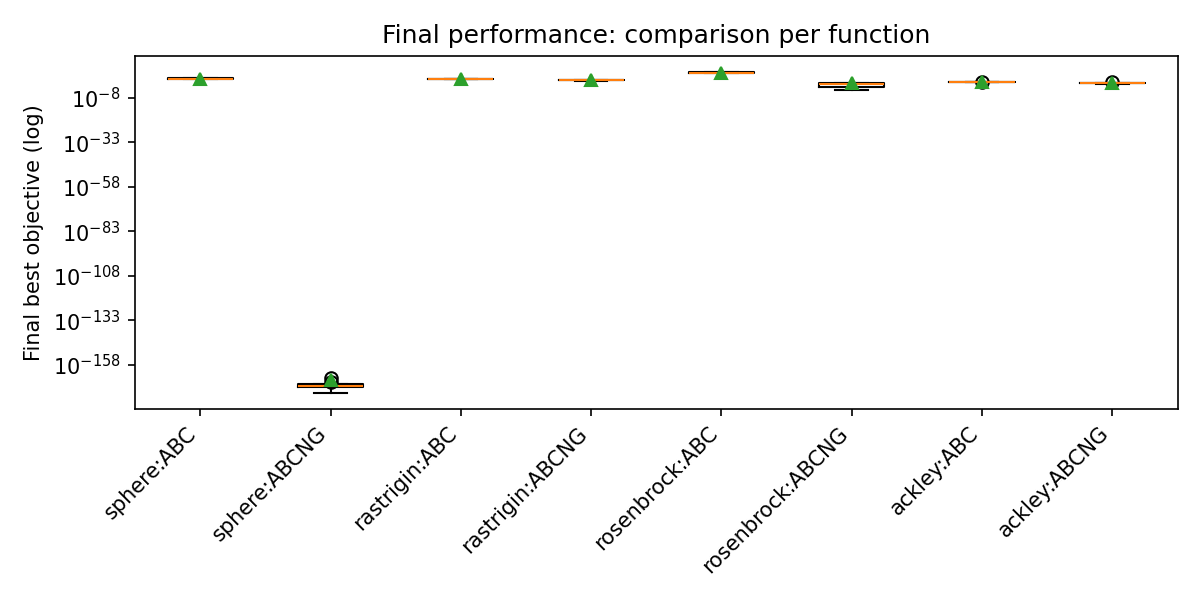

In [4]:
# Heavier quick demo: more runs and broader function set (paper_mode)
from tools.benchmark_plots import (
    summarize_runs,
    plot_convergence,
    plot_k_dynamics,
    plot_convergence_compare,
    plot_box_compare,
)
from IPython.display import display, Image
import numpy as np
import os

functions = ["sphere", "rastrigin", "rosenbrock", "ackley"]
suite = [(name, 30, 15000) for name in functions]
seeds = list(range(1000, 1010))
out_dir = "figs"

rows = []
paths = {"conv": [], "k": [], "compare": [], "box": None}
finals_map = {}

for name, dim, budget in suite:
    sum_ng = summarize_runs(
        name,
        dim,
        budget,
        runs=10,
        seeds=seeds,
        algo="abcng",
        abcng_kwargs={"paper_mode": True},
    )
    sum_abc = summarize_runs(name, dim, budget, runs=10, seeds=seeds, algo="abc")
    conv = plot_convergence(sum_ng, out_dir)
    kplt = plot_k_dynamics(sum_ng, out_dir) if sum_ng["k_median"].size else None
    conv_cmp = plot_convergence_compare(sum_ng, sum_abc, "ABCNG", "ABC", out_dir)

    finals_map[name] = {"ABCNG": sum_ng["finals"], "ABC": sum_abc["finals"]}
    rows.append({
        "function": name,
        "dim": dim,
        "budget": budget,
        "runs": 10,
        "abcng_median_final": float(np.median(sum_ng["finals"])),
        "abc_median_final": float(np.median(sum_abc["finals"])),
    })
    paths["conv"].append(conv)
    if kplt:
        paths["k"].append(kplt)
    paths["compare"].append(conv_cmp)

paths["box"] = plot_box_compare(finals_map, out_dir, labels=("ABC", "ABCNG"))
display(rows)
for p in paths["conv"]:
    display(Image(filename=p))
for p in paths["k"]:
    display(Image(filename=p))
for p in paths["compare"]:
    display(Image(filename=p))
display(Image(filename=paths["box"]))



[{'function': 'sphere',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 2.38217229698558e-170,
  'abc_median_final': 715.3483464338865},
 {'function': 'rastrigin',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 72.63170727411051,
  'abc_median_final': 257.5295883745413},
 {'function': 'rosenbrock',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 0.5643895277184725,
  'abc_median_final': 1411956.0833617076},
 {'function': 'ackley',
  'dim': 30,
  'budget': 15000,
  'runs': 10,
  'abcng_median_final': 2.3619567562648816,
  'abc_median_final': 8.46895551268856}]

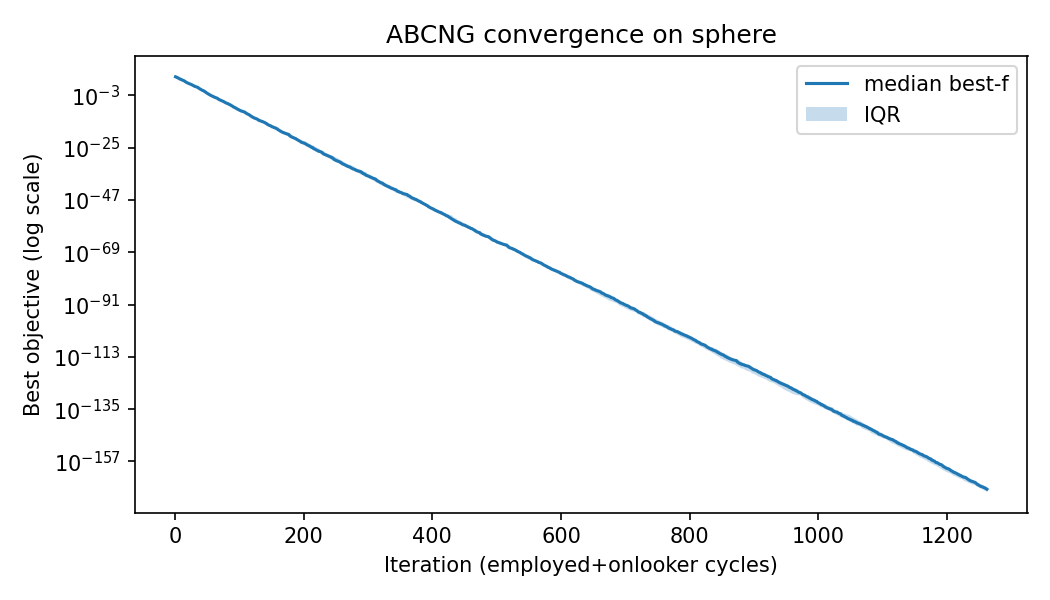

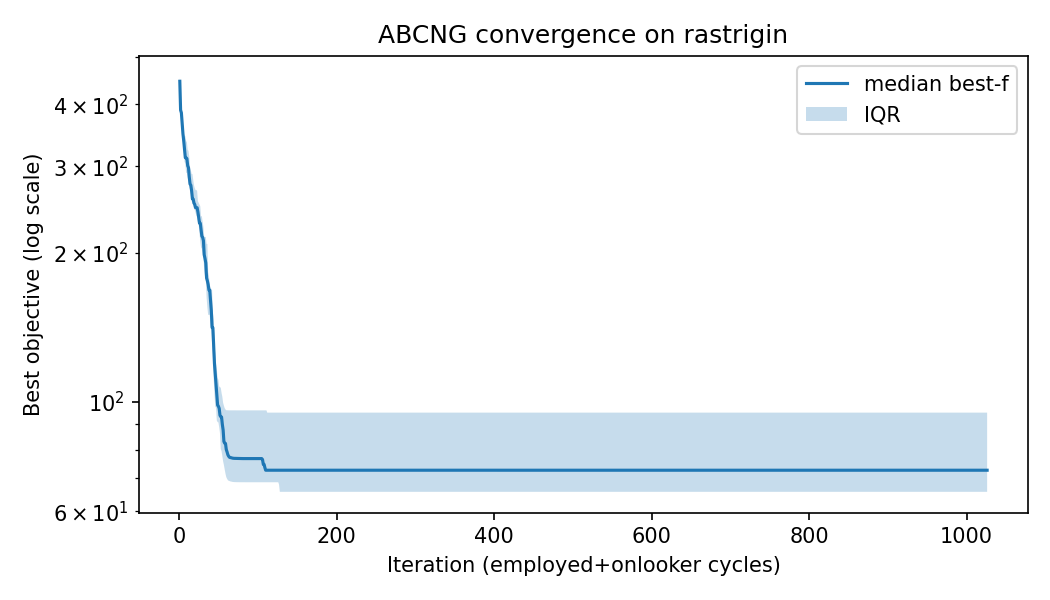

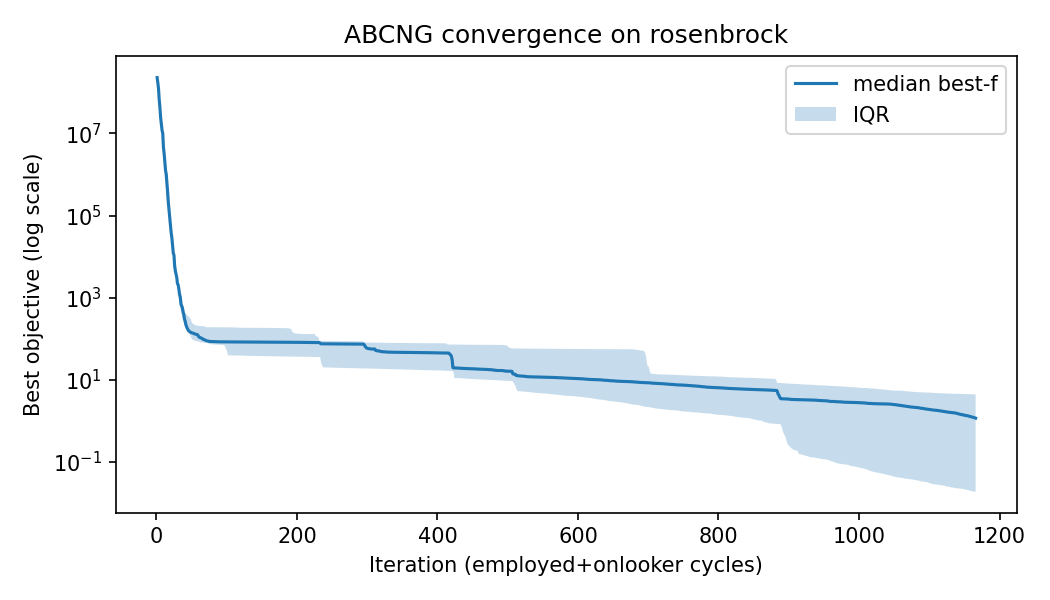

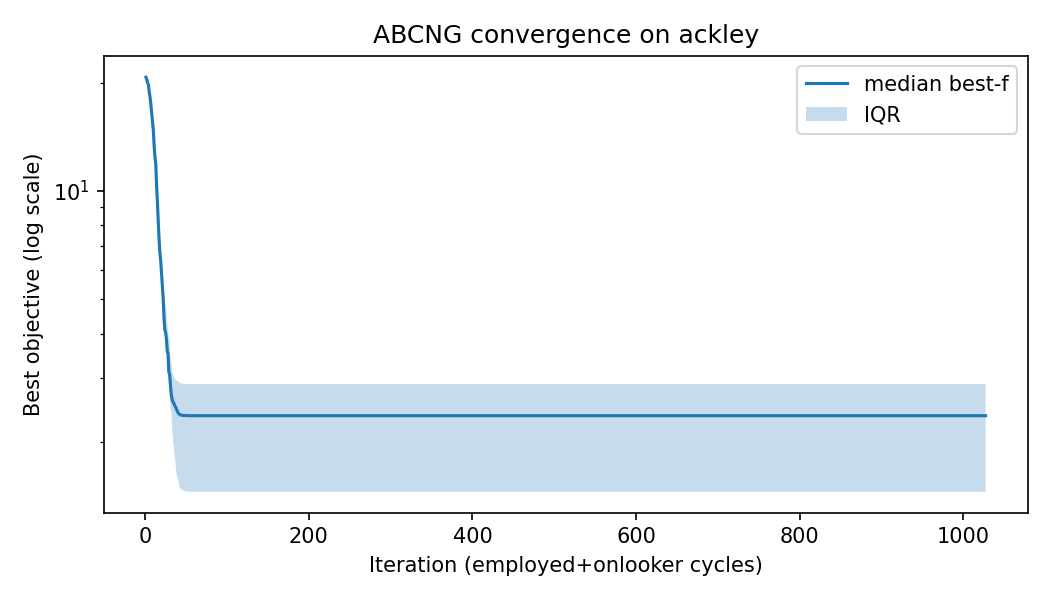

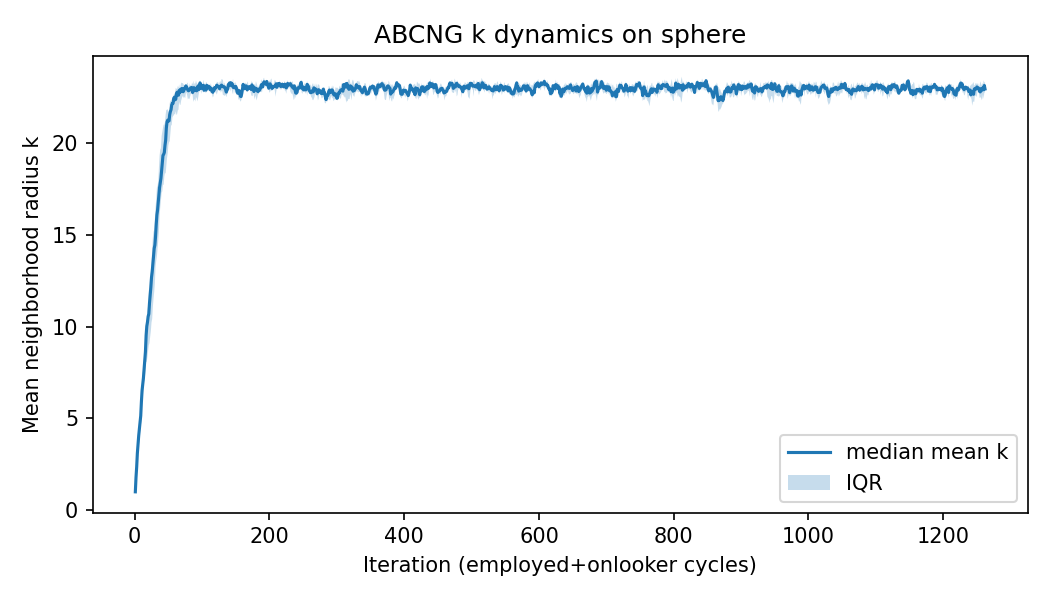

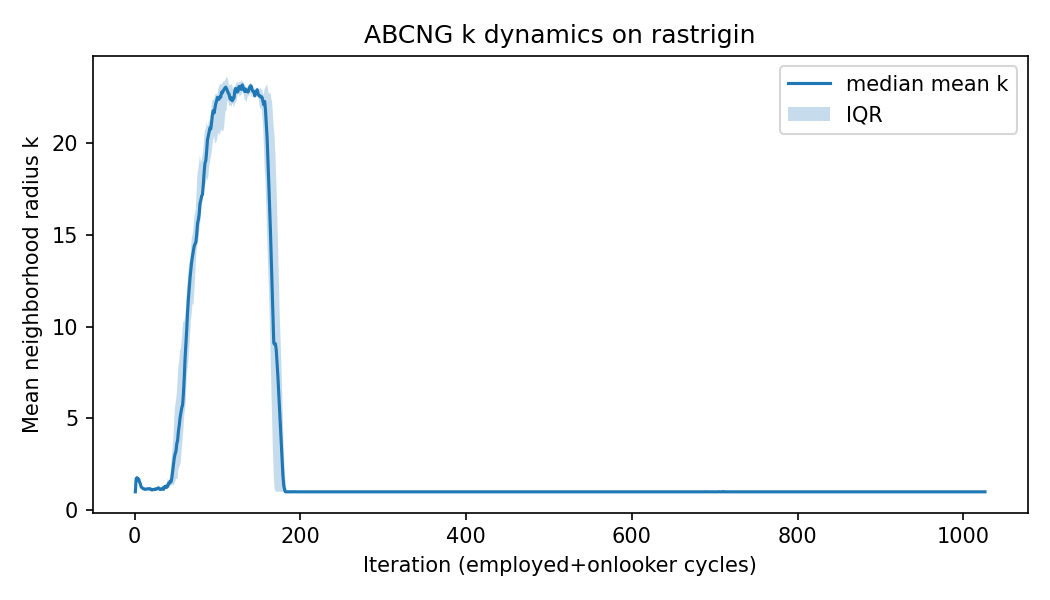

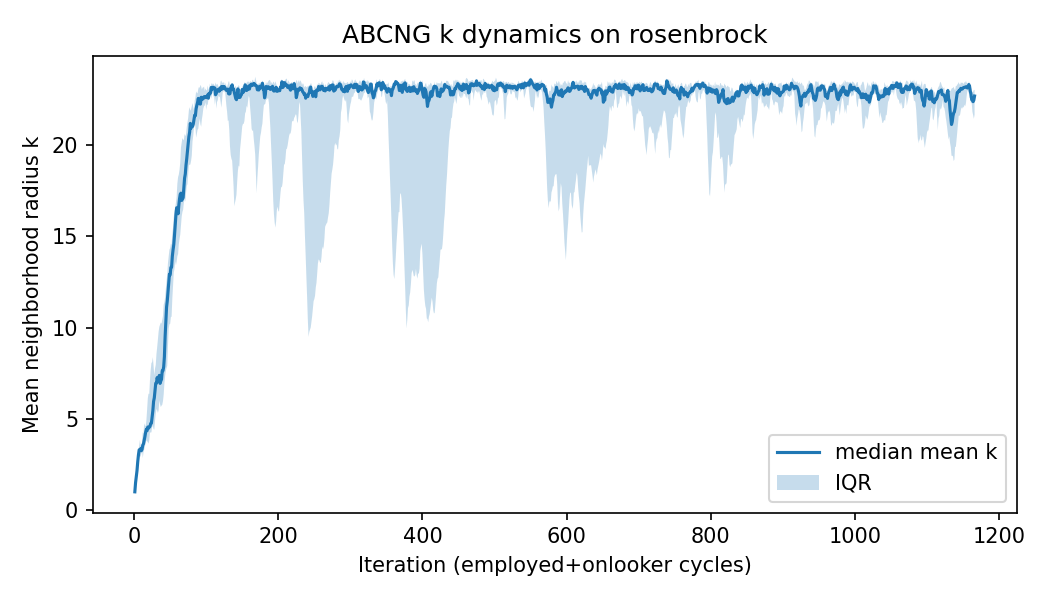

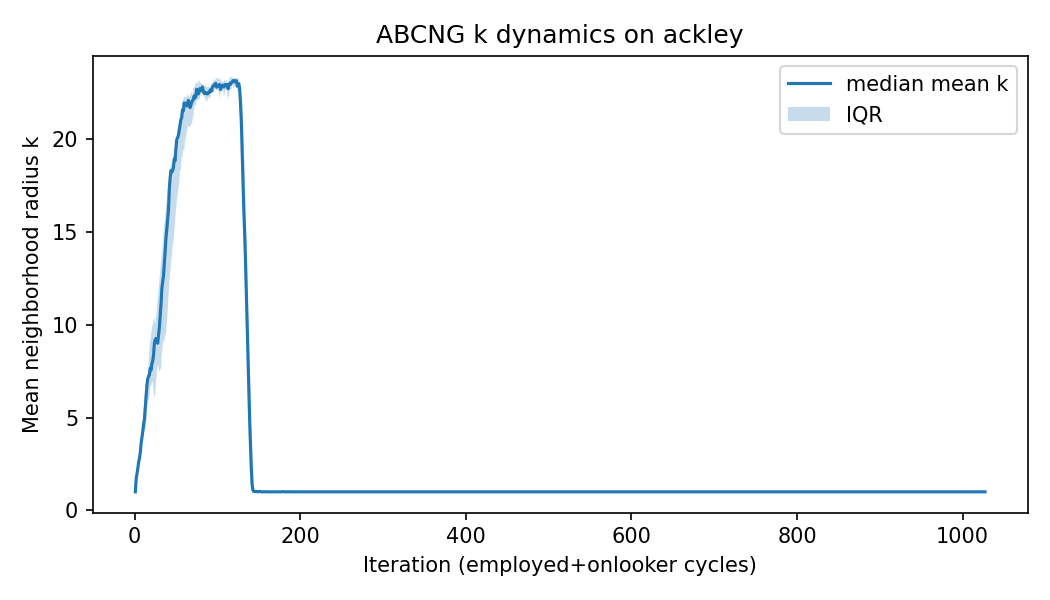

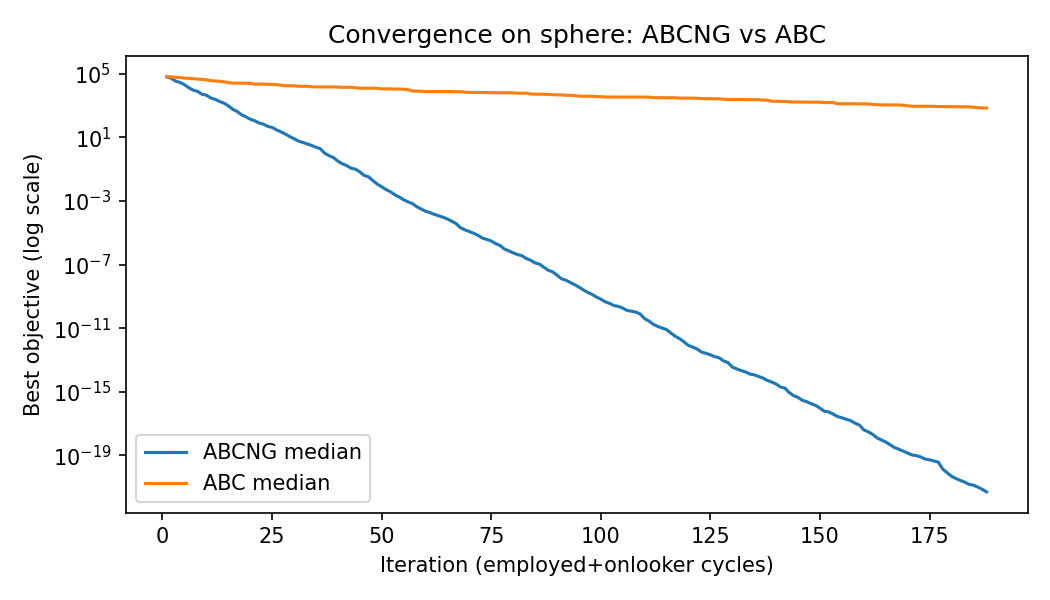

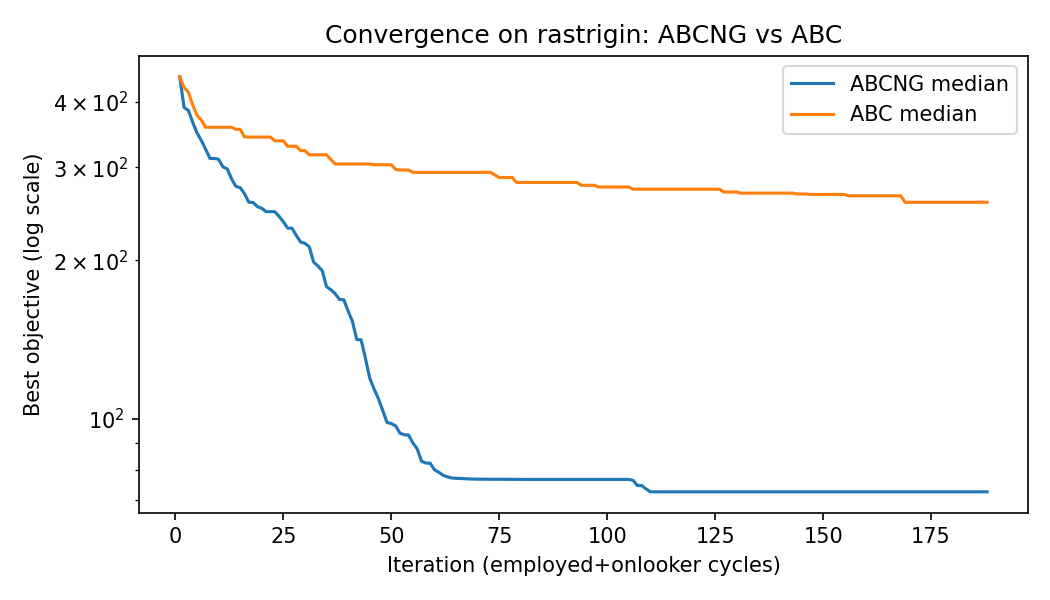

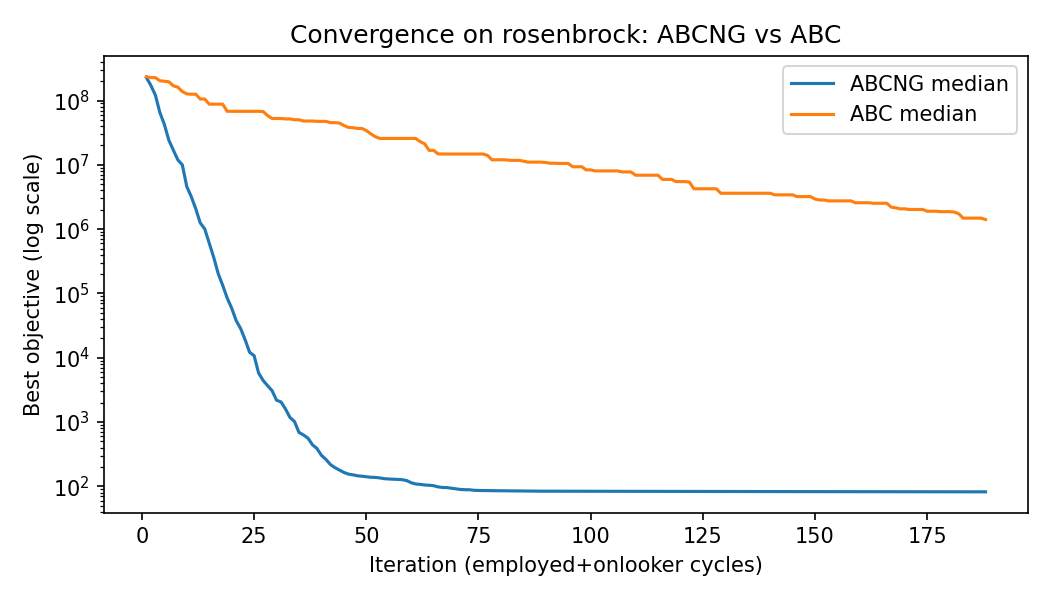

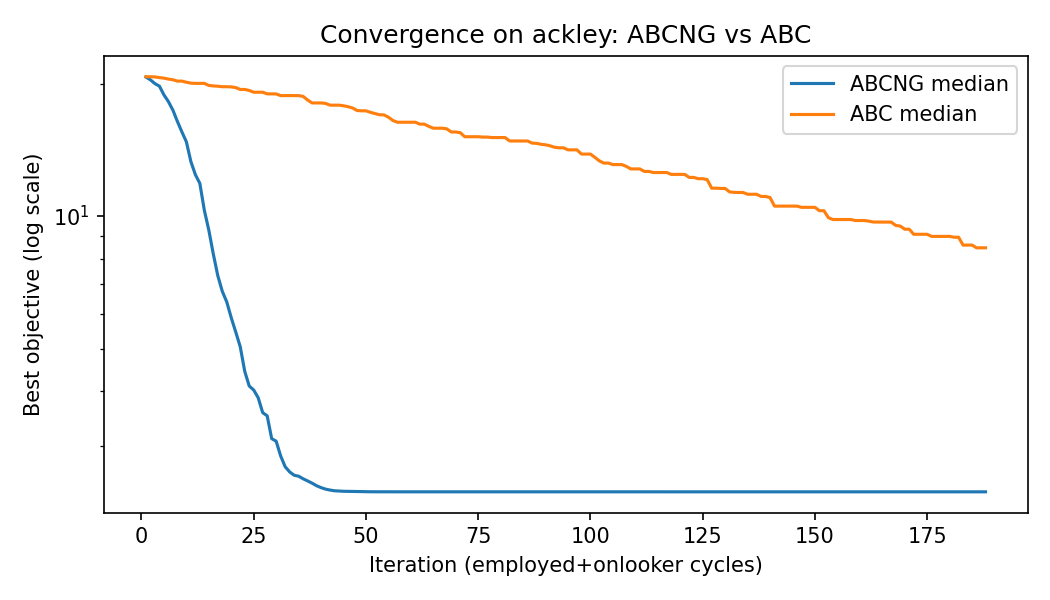

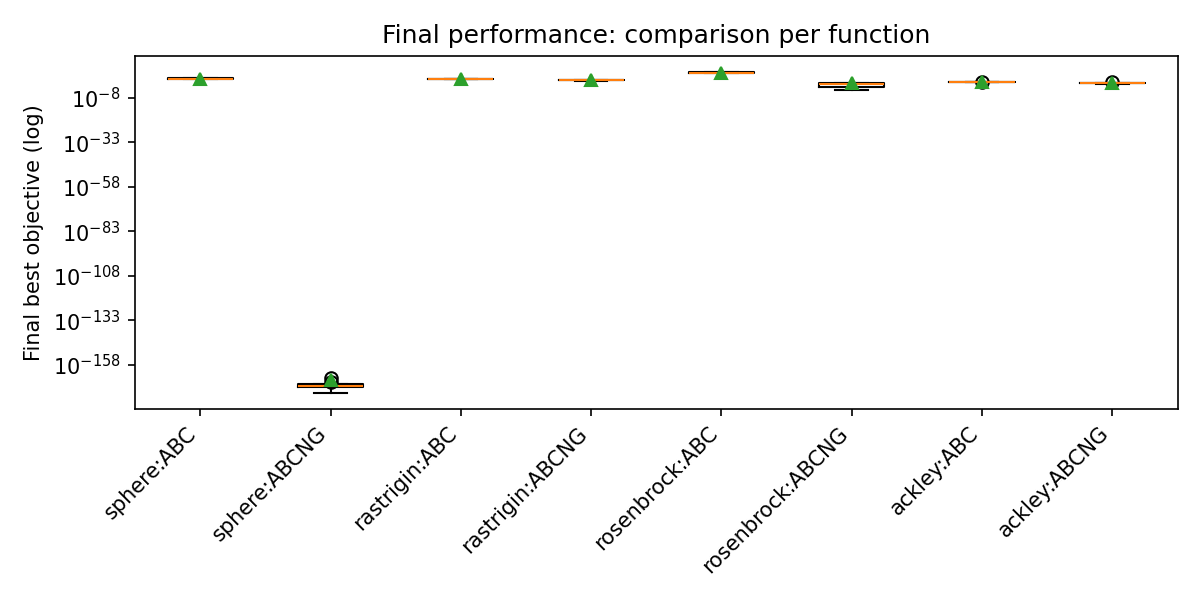

In [5]:
# Heavier quick demo: more runs and broader function set (paper_mode)
from tools.benchmark_plots import (
    summarize_runs,
    plot_convergence,
    plot_k_dynamics,
    plot_convergence_compare,
    plot_box_compare,
)
from IPython.display import display, Image
import numpy as np
import os

functions = ["sphere", "rastrigin", "rosenbrock", "ackley"]
suite = [(name, 30, 15000) for name in functions]
seeds = list(range(1000, 1010))
out_dir = "figs"

rows = []
paths = {"conv": [], "k": [], "compare": [], "box": None}
finals_map = {}

for name, dim, budget in suite:
    sum_ng = summarize_runs(
        name,
        dim,
        budget,
        runs=10,
        seeds=seeds,
        algo="abcng",
        abcng_kwargs={"paper_mode": True},
    )
    sum_abc = summarize_runs(name, dim, budget, runs=10, seeds=seeds, algo="abc")
    conv = plot_convergence(sum_ng, out_dir)
    kplt = plot_k_dynamics(sum_ng, out_dir) if sum_ng["k_median"].size else None
    conv_cmp = plot_convergence_compare(sum_ng, sum_abc, "ABCNG", "ABC", out_dir)

    finals_map[name] = {"ABCNG": sum_ng["finals"], "ABC": sum_abc["finals"]}
    rows.append({
        "function": name,
        "dim": dim,
        "budget": budget,
        "runs": 10,
        "abcng_median_final": float(np.median(sum_ng["finals"])),
        "abc_median_final": float(np.median(sum_abc["finals"])),
    })
    paths["conv"].append(conv)
    if kplt:
        paths["k"].append(kplt)
    paths["compare"].append(conv_cmp)

paths["box"] = plot_box_compare(finals_map, out_dir, labels=("ABC", "ABCNG"))
display(rows)
for p in paths["conv"]:
    display(Image(filename=p))
for p in paths["k"]:
    display(Image(filename=p))
for p in paths["compare"]:
    display(Image(filename=p))
display(Image(filename=paths["box"]))

